Number of customers in each segment: Customer_Segment
Regular Customers           339
High-Value Customers        189
At-Risk Customers           175
Low-Engagement Customers     92
Name: count, dtype: int64

First 5 rows of Customer_segmentation table:
                  Recency  Frequency  Monetary R_Score F_Score M_Score  \
customer_name                                                           
Aaron Bergman         16         89     24646       3       4       4   
Aaron Hawkins         12         56     20759       3       2       4   
Aaron Smayling        23         60     14207       2       2       2   
Adam Bellavance       35         68     20189       1       3       4   
Adam Hart              2         84     21720       4       4       4   

                 RFM_Score      Customer_Segment  
customer_name                                     
Aaron Bergman           11  High-Value Customers  
Aaron Hawkins            9     Regular Customers  
Aaron Smayling           6   

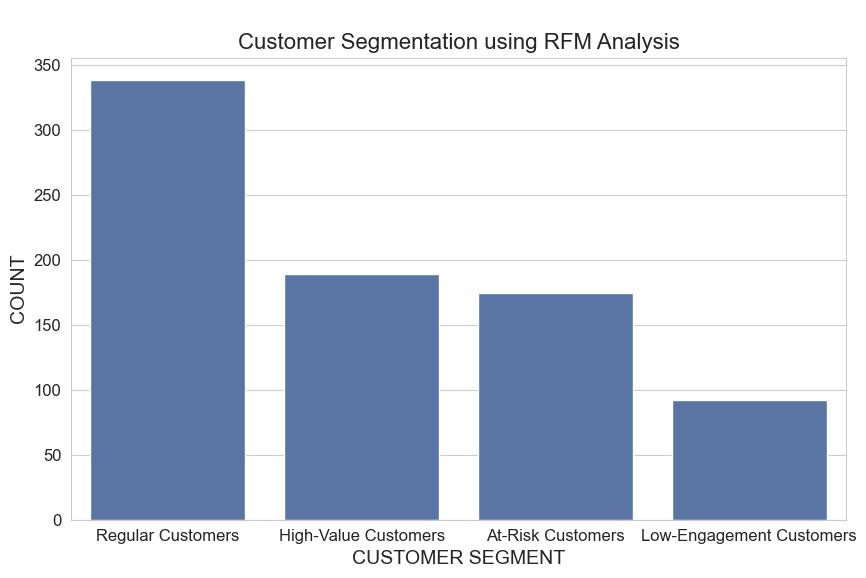


Business interpretation of each segment:

->High-Value Customers:
 Customers with frequent purchases and high spending. 
Important for company profit and retention.

->Regular Customers:
 Customers with consistent purchasing behavior.
Can be converted into high-value customers.

->At-Risk Customers:
 Customers who have not purchased recently.
Need re-engagement strategies.

->Low-Engagement Customers:
 Customers with low purchase activity and spending.
Contribute less to overall revenue.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("SuperStoreOrders_cleaned.xlsx")
df["order_date"]=pd.to_datetime(df["order_date"])
reference_date=df["order_date"].max()                 #finding latest date to calculate recency

#CUSTOMER SEGMENTATION TABLE
rfm_table=df.groupby("customer_name").agg({
    "order_date":lambda x:(reference_date-x.max()).days,
    "order_id":"count",
    "sales":"sum"
})
rfm_table.columns=["Recency","Frequency","Monetary"]  #renaming rfm table columns
rfm_table["R_Score"]=pd.qcut(rfm_table["Recency"],
                             4,                       #Divide the data into 4 equal groups             
                             labels=[4,3,2,1])        #Lower recency=better customer
rfm_table["F_Score"]=pd.qcut(rfm_table["Frequency"].rank(method="first"),     #rank(method='first') gives unique ranking order to avoid errors in qcut()
                             4,
                             labels=[1,2,3,4])        #Higher frequency=better customer
rfm_table["M_Score"]=pd.qcut(rfm_table["Monetary"],
                             4, 
                             labels=[1,2,3,4])        #Higher spending=better customer
rfm_table["RFM_Score"]=(
    rfm_table["R_Score"].astype(int)+
    rfm_table["F_Score"].astype(int)+
    rfm_table["M_Score"].astype(int))
def customer_segment(score):
    if score>=10:
        return "High-Value Customers"
    elif score>=7:
        return "Regular Customers"
    elif score>=5:
        return "At-Risk Customers"
    else:
        return "Low-Engagement Customers"
rfm_table['Customer_Segment'] = rfm_table['RFM_Score'].apply(customer_segment)
Count=rfm_table['Customer_Segment'].value_counts()
print("Number of customers in each segment:",Count)
print("\nFirst 5 rows of Customer_segmentation table:\n",rfm_table.head())
rfm_table.to_excel("Customer_segmentation table.xlsx", index=False)

#VISUALIZATION OF CUSTOMER GROUPS
sns.set_palette("deep")
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.countplot(
    data=rfm_table,
    x='Customer_Segment',
    order=rfm_table['Customer_Segment'].value_counts().index     #control the order of categories in the chart
)
plt.title("\nCustomer Segmentation using RFM Analysis",fontsize=16)
plt.xlabel("CUSTOMER SEGMENT",fontsize=14)
plt.ylabel("COUNT",fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

#BUSINESS INTERPRETATION OF EACH SEGMENT
print("\nBusiness interpretation of each segment:")
print("\n->High-Value Customers:\n","Customers with frequent purchases and high spending.",
"\nImportant for company profit and retention.\n")
print("->Regular Customers:\n","Customers with consistent purchasing behavior."
"\nCan be converted into high-value customers.\n")
print("->At-Risk Customers:\n","Customers who have not purchased recently."
"\nNeed re-engagement strategies.\n")
print("->Low-Engagement Customers:\n","Customers with low purchase activity and spending."
"\nContribute less to overall revenue.")
